# 1. 환경설정

In [1]:
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import networkx as nx
import ast
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [3]:
USER = "root"
PASSWORD = "codeit10!"
HOST = "host.docker.internal"
PORT = 3307
DB = "final"

engine = create_engine(
    f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}"
)

In [4]:
# 폰트 경로 확인
font_paths = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum/'], fontext='ttf')
print(font_paths)

# 폰트 등록
for font in font_paths:
    fm.fontManager.addfont(font)

# matplotlib 기본 폰트 설정
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

['/usr/share/fonts/truetype/nanum/NanumGothic.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareRoundB.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareB.ttf', '/usr/share/fonts/truetype/nanum/NanumMyeongjo.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareR.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf', '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf', '/usr/share/fonts/truetype/nanum/NanumMyeongjoBold.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf', '/usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf']


# 2. 데이터 불러오기

In [5]:
accounts_user_df = pd.read_sql("SELECT * FROM accounts_user", engine)
accounts_attendance_df = pd.read_sql("SELECT * FROM accounts_attendance", engine)
accounts_group_df = pd.read_sql("SELECT * FROM accounts_group", engine)
accounts_nearbyschool_df = pd.read_sql("SELECT * FROM accounts_nearbyschool", engine)
accounts_user_contacts_df = pd.read_sql("SELECT * FROM accounts_user_contacts", engine)
accounts_school_df = pd.read_sql("SELECT * FROM accounts_school", engine)
accounts_userwithdraw_df = pd.read_sql("SELECT * FROM accounts_userwithdraw", engine)

In [6]:
accounts_friendrequest_df = pd.read_sql("SELECT * FROM accounts_friendrequest", engine)
accounts_blockrecord_df = pd.read_sql("SELECT * FROM accounts_blockrecord", engine)
accounts_timelinereport_df = pd.read_sql("SELECT * FROM accounts_timelinereport", engine)

In [7]:
accounts_userquestionrecord_df = pd.read_sql("SELECT * FROM accounts_userquestionrecord", engine)
polls_question_df = pd.read_sql("SELECT * FROM polls_question", engine)
polls_questionpiece_df = pd.read_sql("SELECT * FROM polls_questionpiece", engine)
polls_questionset_df = pd.read_sql("SELECT * FROM polls_questionset", engine)
polls_usercandidate_df = pd.read_sql("SELECT * FROM polls_usercandidate", engine)
polls_questionreport_df = pd.read_sql("SELECT * FROM polls_questionreport", engine)

In [8]:
accounts_paymenthistory_df = pd.read_sql("SELECT * FROM accounts_paymenthistory", engine)
accounts_pointhistory_df = pd.read_sql("SELECT * FROM accounts_pointhistory", engine)
events_df = pd.read_sql("SELECT * FROM events", engine)
event_receipts_df = pd.read_sql("SELECT * FROM event_receipts", engine)

In [59]:
# 불러온 데이터프레임들을 딕셔너리로 정리
dfs = {
    "accounts_user": accounts_user_df,
    "accounts_attendance": accounts_attendance_df,
    "accounts_group": accounts_group_df,
    "accounts_nearbyschool": accounts_nearbyschool_df,
    "accounts_user_contacts": accounts_user_contacts_df,
    "accounts_school": accounts_school_df,
    "accounts_userwithdraw": accounts_userwithdraw_df,
    "accounts_friendrequest": accounts_friendrequest_df,
    "accounts_blockrecord": accounts_blockrecord_df,
    "accounts_timelinereport": accounts_timelinereport_df,
    "accounts_userquestionrecord": accounts_userquestionrecord_df,
    "polls_question": polls_question_df,
    "polls_questionpiece": polls_questionpiece_df,
    "polls_questionset": polls_questionset_df,
    "polls_usercandidate": polls_usercandidate_df,
    "polls_questionreport": polls_questionreport_df,
    "accounts_paymenthistory": accounts_paymenthistory_df,
    "accounts_pointhistory": accounts_pointhistory_df,
    "events": events_df,
    "event_receipts": event_receipts_df
}

# 중복치 & 결측치 일괄 출력
for name, df in dfs.items():
    print(f"\n===== {name} =====")
    print(f"행 개수: {len(df)}")
    print(f"중복 행 수: {df.duplicated().sum()}")
    print("결측치 개수:")
    print(df.isnull().sum())



===== accounts_user =====
행 개수: 677085
중복 행 수: 0
결측치 개수:
id                    0
is_superuser          0
is_staff              0
gender                2
point                 0
friend_id_list        0
is_push_on            0
created_at            0
block_user_id_list    0
hide_user_id_list     0
ban_status            0
report_count          0
alarm_count           0
pending_chat          0
pending_votes         0
group_id              3
year_month            0
dtype: int64

===== accounts_attendance =====
행 개수: 349637
중복 행 수: 0
결측치 개수:
id                      0
attendance_date_list    0
user_id                 0
dtype: int64

===== accounts_group =====
행 개수: 84515
중복 행 수: 0
결측치 개수:
id           0
grade        0
class_num    0
school_id    0
dtype: int64

===== accounts_nearbyschool =====
행 개수: 59500
중복 행 수: 0
결측치 개수:
id                  0
distance            0
nearby_school_id    0
school_id           0
dtype: int64

===== accounts_user_contacts =====
행 개수: 5063
중복 행 수: 0
결측치 개수:
id  

# 3. EDA & 전처리

## 3.1 기본 분포

### 3.1.1 사용자 분포

In [10]:
# 3.1.1 사용자 분포
print("👥 사용자 수:", accounts_user_df['id'].nunique())
print("\n🏫 학교 수:", accounts_school_df.shape[0])

👥 사용자 수: 677085

🏫 학교 수: 5951


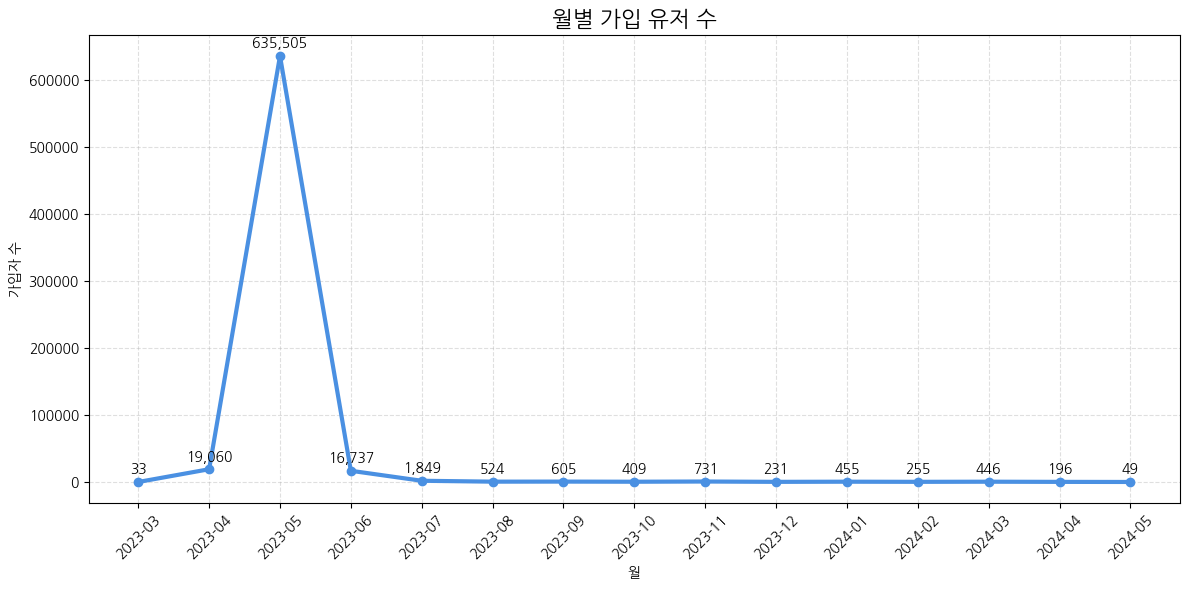

In [11]:
# created_at을 datetime으로 변환
accounts_user_df['created_at'] = pd.to_datetime(accounts_user_df['created_at'])

# 월 단위로 그룹핑
accounts_user_df['year_month'] = accounts_user_df['created_at'].dt.to_period('M')
monthly_counts = accounts_user_df.groupby('year_month').size()

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(monthly_counts.index.astype(str), monthly_counts.values,
         marker='o', linewidth=3, color='#4A90E2')

plt.title('월별 가입 유저 수', fontsize=16)
plt.xlabel('월')
plt.ylabel('가입자 수')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)

# 값 표시
for i, v in enumerate(monthly_counts.values):
    plt.text(i, v + max(monthly_counts.values)*0.02, f"{v:,}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### 3.1.2 투표 기록 퍼널 분석

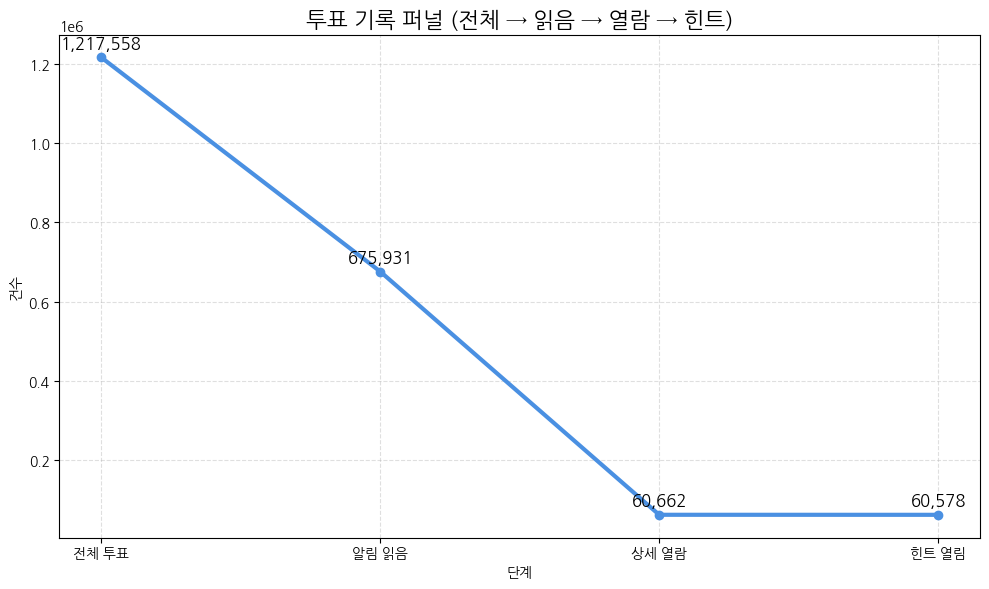

In [12]:
# 3.1.2 투표 기록 퍼널 분석
# 1) 퍼널 단계별 값 계산
total_votes = len(accounts_userquestionrecord_df)
read_votes = accounts_userquestionrecord_df['has_read'].sum()
opened_votes = (accounts_userquestionrecord_df['opened_times'] > 0).sum()
hint_opened = (accounts_userquestionrecord_df['status'] == 'I').sum()

# 2) 퍼널 데이터 구성
stages = ['전체 투표', '알림 읽음', '상세 열람', '힌트 열림']
values = [total_votes, read_votes, opened_votes, hint_opened]

# 3) 시각화
plt.figure(figsize=(10, 6))
plt.plot(stages, values, marker='o', linewidth=3, color='#4A90E2')
plt.title('투표 기록 퍼널 (전체 → 읽음 → 열람 → 힌트)', fontsize=16)
plt.xlabel('단계')
plt.ylabel('건수')
plt.grid(True, linestyle='--', alpha=0.4)

# 값 표시
for i, v in enumerate(values):
    plt.text(i, v + max(values)*0.02, f"{v:,}", ha='center', fontsize=12)

plt.tight_layout()
plt.show()

### 3.1.3 후보 노출 및 신고 현황

In [13]:
# 3.1.3 후보 노출 및 신고 현황
chosen_counts = accounts_userquestionrecord_df.groupby("chosen_user_id").size()

def gini(array):
    array = np.array(array, dtype=float)
    array = array.flatten()
    
    if np.amin(array) < 0:
        array -= np.amin(array)
        
    array += 1e-9  # 0 division 방지
    array = np.sort(array)
    
    n = array.shape[0]
    cumulative = np.cumsum(array)
    
    gini_coeff = (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n
    return gini_coeff


gini_value = gini(chosen_counts.values)

print("선택받은 횟수의 Gini 계수:", gini_value)

선택받은 횟수의 Gini 계수: 0.7235670038738862


In [14]:
# 후보로 등장한 횟수 집계
exposure_counts = polls_usercandidate_df.groupby("user_id").size()

# Gini 계산
gini_exposure = gini(exposure_counts.values)

print("후보 노출 횟수의 Gini 계수:", gini_exposure)

후보 노출 횟수의 Gini 계수: 0.7683348687085406


In [15]:
def top_share(counts, top_ratio):
    counts = counts.sort_values(ascending=False)
    n = len(counts)
    top_n = int(n * top_ratio)
    return counts.iloc[:top_n].sum() / counts.sum()

print("상위 1% 점유율:", top_share(chosen_counts, 0.01))
print("상위 5% 점유율:", top_share(chosen_counts, 0.05))
print("상위 10% 점유율:", top_share(chosen_counts, 0.10))


상위 1% 점유율: 0.08987580057787802
상위 5% 점유율: 0.3184373968221637
상위 10% 점유율: 0.5139935838785503


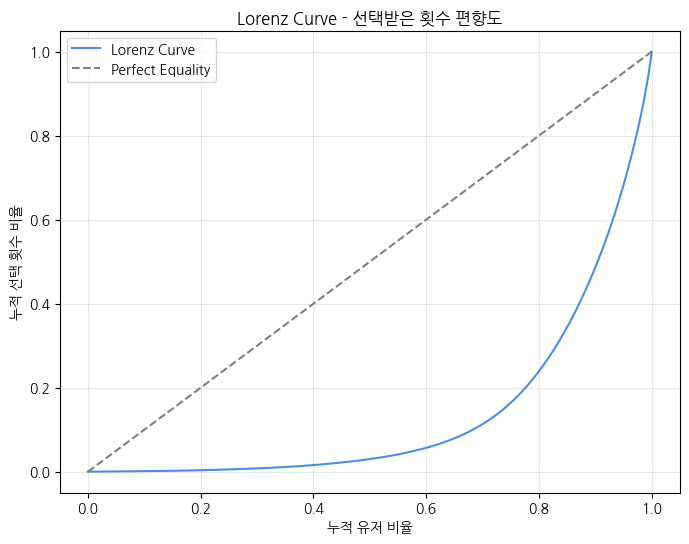

In [16]:
# Lorenz Curve 계산
values = chosen_counts.values.astype(float)
values_sorted = np.sort(values)
cum_values = np.cumsum(values_sorted)
cum_values = np.insert(cum_values, 0, 0)  # 0부터 시작
cum_values = cum_values / cum_values[-1]  # 전체 대비 비율

n = len(values)
cum_users = np.arange(0, n+1) / n  # 유저 누적 비율

# 시각화
plt.figure(figsize=(8, 6))
plt.plot(cum_users, cum_values, label="Lorenz Curve", color="#4A90E2")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect Equality")

plt.title("Lorenz Curve - 선택받은 횟수 편향도")
plt.xlabel("누적 유저 비율")
plt.ylabel("누적 선택 횟수 비율")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### 3.1.4 포인트 사용 현황

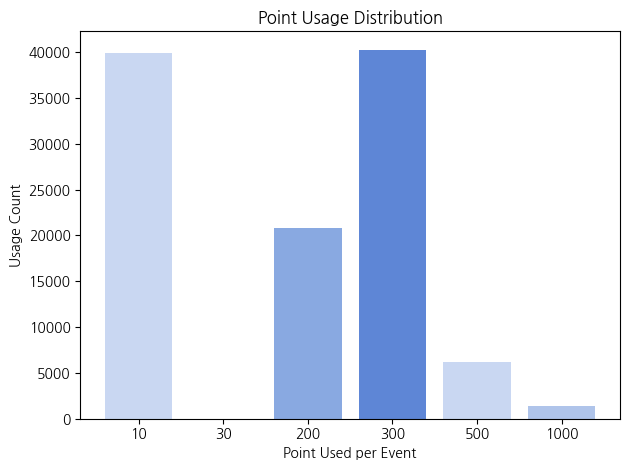

In [50]:
query3 = """
SELECT
    -delta_point AS point_used,
    COUNT(*) AS usage_count
FROM accounts_pointhistory
WHERE delta_point < 0
GROUP BY -delta_point
ORDER BY point_used;
"""

df_count = pd.read_sql(sql=query3, con=engine)

# 시각화

baby_blue_4 = [
    "#C9D7F2",  # Very Light Baby Blue
    "#AFC4EA",  # Soft Blue
    "#89A9E1",  # Medium Baby Blue
    "#5E86D6"   # Deep Baby Blue
]

plt.figure()
plt.bar(
    df_count['point_used'].astype(str),  # 카테고리화
    df_count['usage_count'],
    color=baby_blue_4
)
plt.xlabel('Point Used per Event')
plt.ylabel('Usage Count')
plt.title('Point Usage Distribution')
plt.tight_layout()
plt.show()

In [17]:
# 3.1.4 포인트 사용 현황
df_user = accounts_user_df.copy()
df_user['friend_count'] = df_user['friend_id_list'].apply(lambda x: len(x) if x else 0)

# 차단 / 숨김 유저 수 계산
df_user['block_count'] = df_user['block_user_id_list'].apply(lambda x: len(x) if x else 0)
df_user['hide_count'] = df_user['hide_user_id_list'].apply(lambda x: len(x) if x else 0)

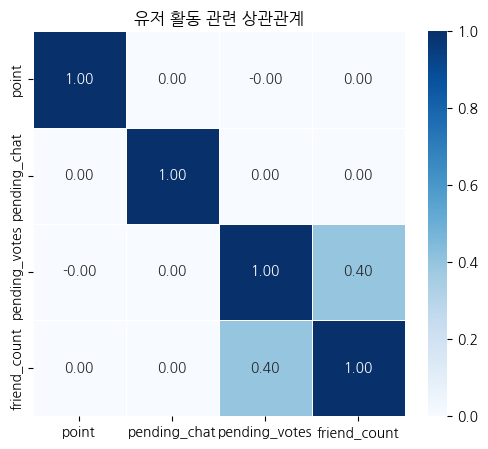

In [18]:
activity_cols = ['point', 'pending_chat', 'pending_votes', 'friend_count']

# 상관계수 계산
corr = df_user[activity_cols].corr()

# friend_id_list 길이 계산
df_user['friend_count'] = df_user['friend_id_list'].apply(lambda x: len(x) if x else 0)

# 차단 / 숨김 유저 수 계산
df_user['block_count'] = df_user['block_user_id_list'].apply(lambda x: len(x) if x else 0)
df_user['hide_count'] = df_user['hide_user_id_list'].apply(lambda x: len(x) if x else 0)

plt.figure(figsize=(6,5))
sns.heatmap(
    corr,
    annot=True,
    cmap='Blues',     # 💙 하늘–파랑 계열
    vmin=0, vmax=1,   # 양의 상관관계 중심일 때 추천
    linewidths=0.5,
    fmt=".2f"
)
plt.title("유저 활동 관련 상관관계")
plt.show()

## 3.2 핵심 지표

### 3.2.1 투표 참여 WAU/MAU

In [19]:
# 3.2.1 투표 참여 WAU/MAU
mau_df = accounts_userquestionrecord_df.copy()

# 날짜 컬럼을 datetime으로 변환
mau_df['created_at'] = pd.to_datetime(mau_df['created_at'])

# 주 단위, 월 단위 user_id unique count
wau = mau_df.groupby(pd.Grouper(key='created_at', freq='W'))['user_id'].nunique()
mau = mau_df.groupby(pd.Grouper(key='created_at', freq='MS'))['user_id'].nunique()

# WAU/MAU 비율 계산
wau_mau_ratio = (wau / mau.reindex(wau.index, method='ffill'))

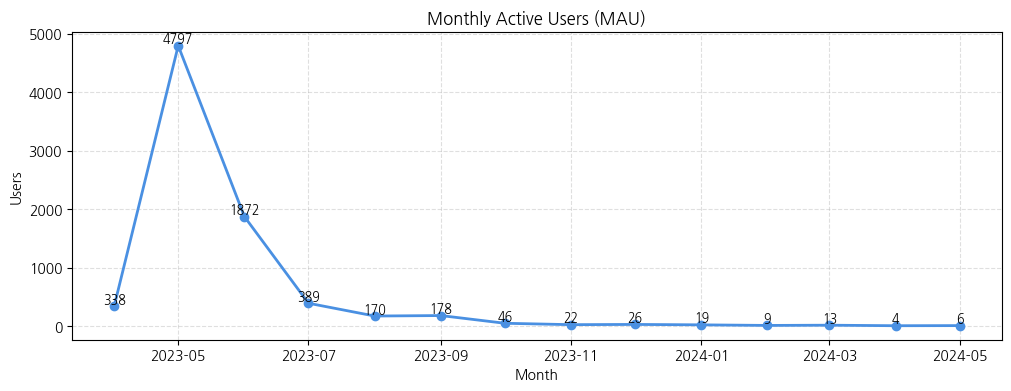

In [20]:
# WAU/MAU 비율 (월 기준으로 맞추기)
wau_monthly = wau.resample('ME').mean()
ratio = wau_monthly / mau


# MAU
plt.figure(figsize=(12,4))
plt.plot(mau.index, mau.values, marker='o', linewidth=2, color='#4A90E2')

for x, y in zip(mau.index, mau.values): plt.text(x, y, str(y), fontsize=9, ha='center', va='bottom')

plt.gca().set_facecolor('white')
plt.title("Monthly Active Users (MAU)")
plt.xlabel("Month")
plt.ylabel("Users")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

In [21]:
# 주간 데이터를 월로 매핑
wau.index = wau.index.to_period('M').to_timestamp()

# 2023-04 같은 불필요한 월 제거
wau = wau[wau.index >= '2023-05-01']

wau_monthly = wau.resample('MS').mean()  # 월 첫날 기준으로 맞추기

# WAU/MAU 비율
ratio = wau_monthly / mau

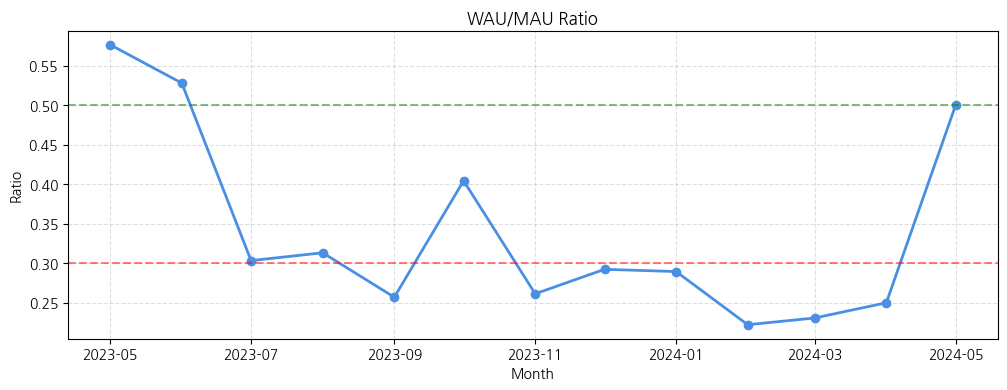

In [22]:
# WAU/MAU Ratio
plt.figure(figsize=(12,4))
plt.plot(ratio.index, ratio.values, marker='o', linewidth=2, color='#4A90E2')
plt.axhline(0.5, color='green', linestyle='--', alpha=0.5)
plt.axhline(0.3, color='red', linestyle='--', alpha=0.5)
plt.title("WAU/MAU Ratio")
plt.xlabel("Month")
plt.ylabel("Ratio")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

### 3.2.2 MRR

In [23]:
# 3.2.2 MRR
# 가격 매핑
price_map = {
    'heart.200': 900,
    'heart.777': 1900,
    'heart.1000': 2900,
    'heart.4000': 9900
}

df = accounts_paymenthistory_df.copy()
df['created_at'] = pd.to_datetime(df['created_at'])

# 가격 컬럼 추가
df['price'] = df['productId'].map(price_map)

# 월별 MRR 계산
mrr = df.groupby(pd.Grouper(key='created_at', freq='MS'))['price'].sum()

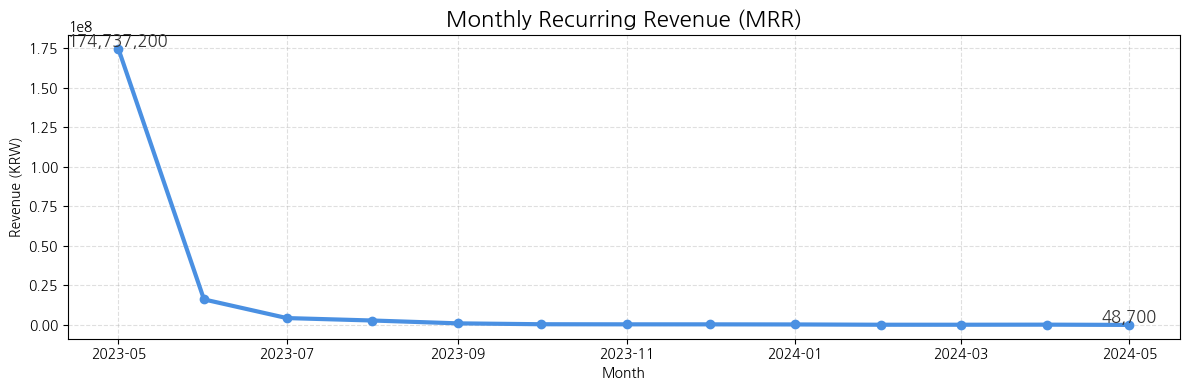

In [24]:
plt.figure(figsize=(12,4))
plt.plot(mrr.index, mrr.values, marker='o', linewidth=3, color='#4A90E2')

# 최고점
max_idx = mrr.idxmax()
max_val = mrr.max()
plt.text(max_idx, max_val, f"{max_val:,}", fontsize=12, ha='center', va='bottom', color='#333333')

# 최저점
min_idx = mrr.idxmin()
min_val = mrr.min()
plt.text(min_idx, min_val, f"{min_val:,}", fontsize=12, ha='center', va='bottom', color='#333333')

plt.title("Monthly Recurring Revenue (MRR)", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue (KRW)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 3.2.3 유지율/재구매율

In [25]:
# 3.2.3 유지율/재구매율
monthly_users = mau_df.groupby(pd.Grouper(key='created_at', freq='MS'))['user_id'].apply(set)
# 유지율 계산
retention = {}
months = list(monthly_users.index)   # ← monthly_users 기준으로 변경

for i in range(len(months)-1):
    m1 = months[i]
    m2 = months[i+1]
    users_m1 = monthly_users[m1]
    users_m2 = monthly_users[m2]
    
    if len(users_m1) > 0:
        retention[m2] = len(users_m1 & users_m2) / len(users_m1)
    else:
        retention[m2] = None

retention = pd.Series(retention)

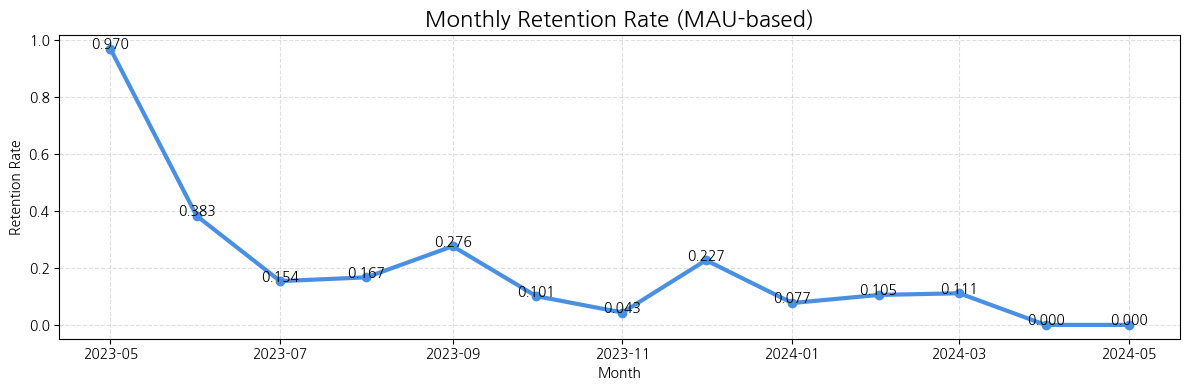

In [26]:
plt.figure(figsize=(12,4))
plt.plot(retention.index, retention.values, marker='o', linewidth=3, color='#4A90E2')

# 값 표시
for x, y in zip(retention.index, retention.values):
    if y is not None:
        plt.text(x, y + 0.002, f"{y:.3f}", ha='center', fontsize=10)

plt.title("Monthly Retention Rate (MAU-based)", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Retention Rate")

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [27]:
df_pay = accounts_paymenthistory_df.copy()
df_pay['created_at'] = pd.to_datetime(df_pay['created_at'])

# 월별 결제 사용자 집합
monthly_payers = df_pay.groupby(pd.Grouper(key='created_at', freq='MS'))['user_id'].apply(set)

# 재구매율 계산
repurchase = {}
months = list(monthly_payers.index)

for i in range(len(months)-1):
    m1 = months[i]
    m2 = months[i+1]
    payers_m1 = monthly_payers[m1]
    payers_m2 = monthly_payers[m2]
    
    if len(payers_m1) > 0:
        repurchase[m2] = len(payers_m1 & payers_m2) / len(payers_m1)
    else:
        repurchase[m2] = None

repurchase = pd.Series(repurchase)

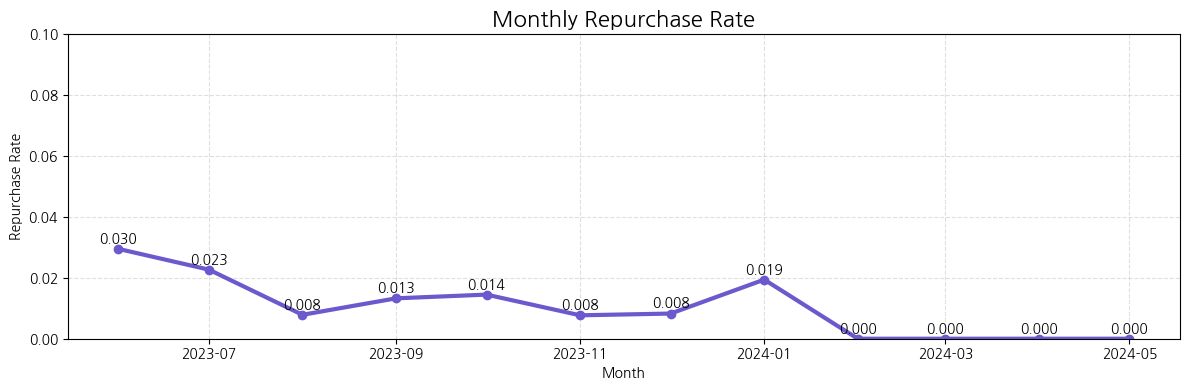

In [28]:
plt.figure(figsize=(12,4))
plt.plot(repurchase.index, repurchase.values, marker='o', linewidth=3, color='#6A5ACD')

# 값 표시
for x, y in zip(repurchase.index, repurchase.values):
    if y is not None:
        plt.text(x, y + 0.002, f"{y:.3f}", ha='center', fontsize=10)

plt.title("Monthly Repurchase Rate", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Repurchase Rate")

# 재구매율도 매우 낮을 가능성이 높으므로 확대
plt.ylim(0, 0.1)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 3.3 서비스 전환점 (이탈 구간)

### 3.3.1 투표 이벤트 추이 분석

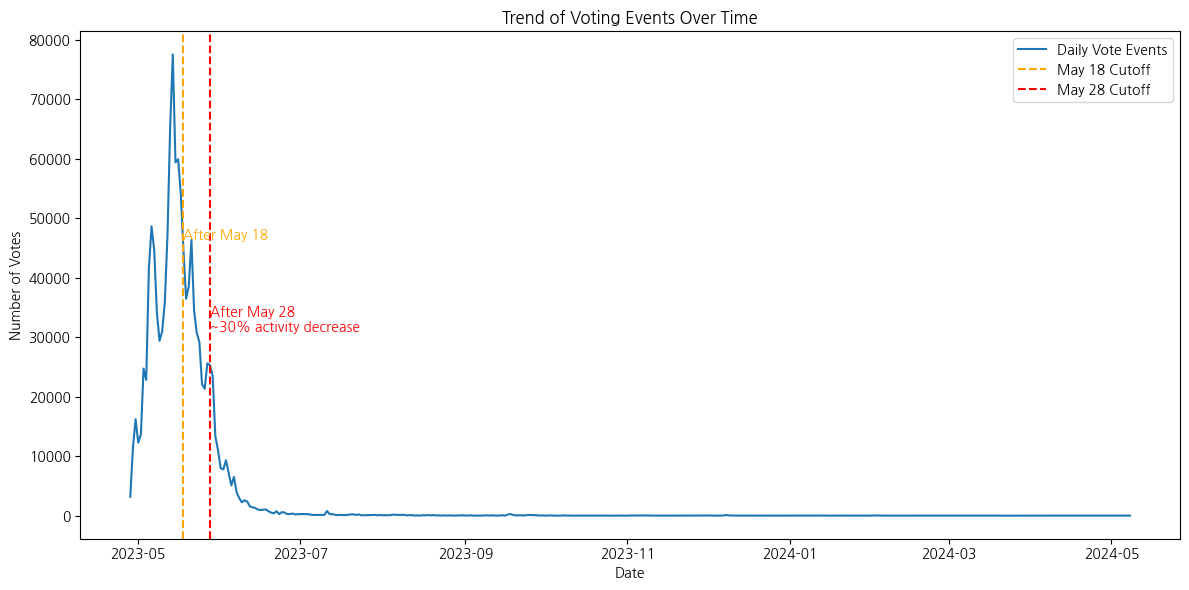

In [48]:
# 3.3.1 투표 이벤트 추이 분석
# 일별 투표 수 집계
mau_df['date'] = mau_df['created_at'].dt.date
daily_votes = mau_df.groupby('date')['id'].count()

# 기준일
cutoff = pd.to_datetime("2023-05-28").date()
cutoff_2 = pd.to_datetime("2023-05-18").date()
cutoff_3 = pd.to_datetime("2023-06-22").date()

plt.figure(figsize=(12,6))
plt.plot(daily_votes.index, daily_votes.values, label="Daily Vote Events")

plt.axvline(cutoff_2, color='orange', linestyle='--', label="May 18 Cutoff")
plt.text(cutoff_2, max(daily_votes)*0.6,
         "After May 18",
         color='orange')

plt.axvline(cutoff, color='red', linestyle='--', label="May 28 Cutoff")
plt.text(cutoff, max(daily_votes)*0.4,
         "After May 28\n~30% activity decrease",
         color='red')

plt.title("Trend of Voting Events Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Votes")
plt.legend()
plt.tight_layout()
plt.show()

### 3.3.2 이탈 발생 전환 구간 분석

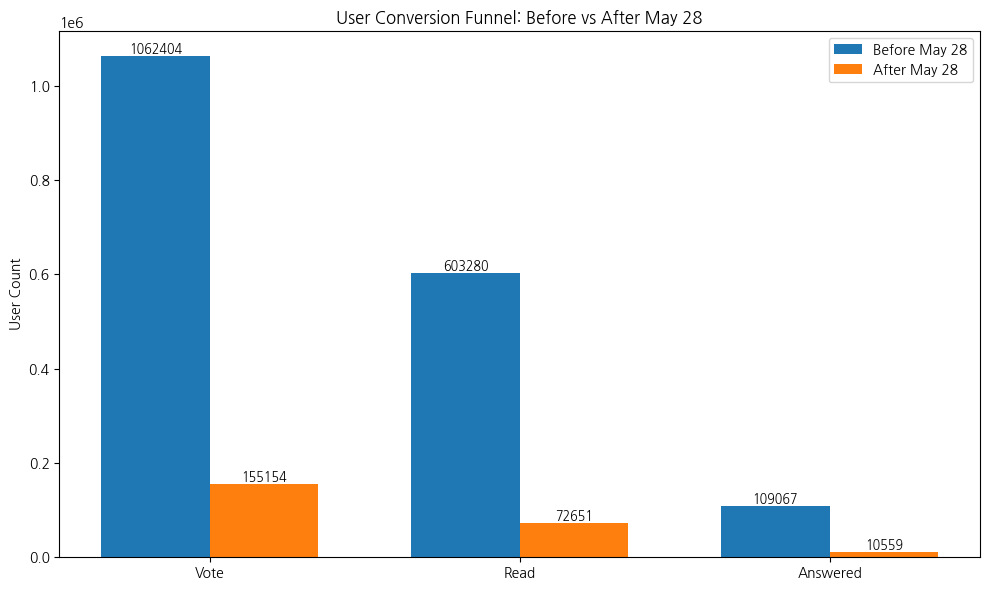

In [49]:
# 3.3.2 이탈 발생 전환 구간 분석
cutoff_date = "2023-05-28"

before = mau_df[mau_df['created_at'] < cutoff_date]
after = mau_df[mau_df['created_at'] >= cutoff_date]

def get_funnel(data):
    total = len(data)
    read = len(data[data['has_read'] == 1])
    answered = len(data[data['answer_status'] != 'N'])
    return [total, read, answered]

before_funnel = get_funnel(before)
after_funnel = get_funnel(after)

labels = ["Vote", "Read", "Answered"]


x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width/2, before_funnel, width, label="Before May 28")
bars2 = plt.bar(x + width/2, after_funnel, width, label="After May 28")

plt.xticks(x, labels)
plt.ylabel("User Count")
plt.title("User Conversion Funnel: Before vs After May 28")
plt.legend()

# 수치 표시
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

before_read_rate = before['has_read'].mean()
after_read_rate = after['has_read'].mean()

# 4. 이탈 기간 집중 클러스터링

In [51]:
query = """
SELECT
    p1.user_id,
    p2.chosen_count - p1.chosen_count AS delta_chosen,
    p2.active_days  - p1.active_days  AS delta_active_days,
    p2.chosen_per_active_day - p1.chosen_per_active_day AS delta_intensity,
    p2.read_exposure_rate - p1.read_exposure_rate AS delta_read_rate,
    p2.total_report_count - p1.total_report_count AS delta_report
FROM user_agg_period_v3 p1
JOIN user_agg_period_v3 p2
  ON p1.user_id = p2.user_id
WHERE p1.period = 'p1'
  AND p2.period = 'p2';
"""

In [52]:
df = pd.read_sql(query, engine)
df.head()

,user_id,delta_chosen,delta_active_days,delta_intensity,delta_read_rate,delta_report
0,838466,-125,-5,-19.1667,-0.2126,0.0
1,839357,-198,-7,-18.6250,0.1993,0.0
2,840473,-52,1,-6.0727,-0.0164,0.0
3,840685,-515,-7,-34.9286,0.1932,0.0
4,840902,-240,-12,-13.8462,0.1306,0.0


In [53]:
X = df.fillna(0)
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster_id'] = kmeans.fit_predict(X_scaled)

In [54]:
## 클러스터 크기 분포
df['cluster_id'].value_counts().sort_index()

cluster_id
0     645
1    1063
2    1093
Name: count, dtype: int64

In [55]:
## 클러스터별 평균(센터)로 "유형" 정의하기
features = [
    'delta_chosen',
    'delta_active_days',
    'delta_intensity',
    'delta_read_rate',
    'delta_report'
]

cluster_profile = df.groupby('cluster_id')[features].mean().round(4)
cluster_profile


,delta_chosen,delta_active_days,delta_intensity,delta_read_rate,delta_report
cluster_id,,,,,
0,-218.7318,0.5504,-43.7493,-0.1799,-0.1271
1,9.2512,2.9454,-10.7677,-0.1450,0.0009
2,-193.1930,-5.2553,-15.6884,-0.0786,-0.0329


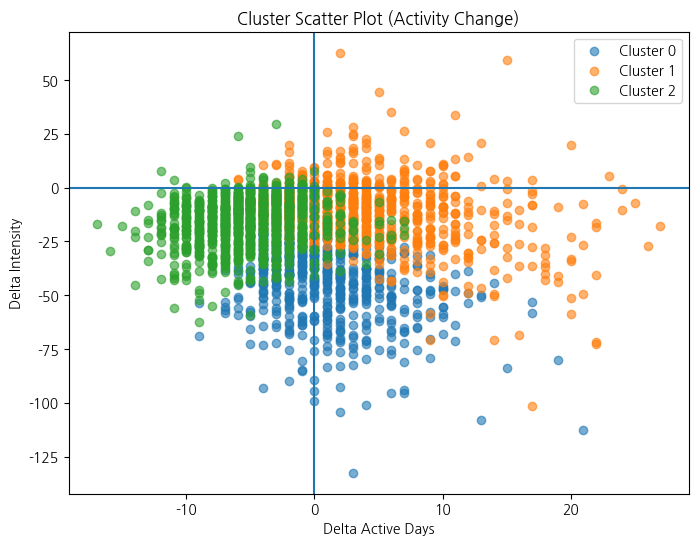

In [56]:
# 1. 활동 변화 기준 산점도
plt.figure(figsize=(8,6))

for cluster in sorted(df['cluster_id'].unique()):
    subset = df[df['cluster_id'] == cluster]
    plt.scatter(
        subset['delta_active_days'],
        subset['delta_intensity'],
        label=f'Cluster {cluster}',
        alpha=0.6
    )

plt.axhline(0)
plt.axvline(0)

plt.xlabel('Delta Active Days')
plt.ylabel('Delta Intensity')
plt.title('Cluster Scatter Plot (Activity Change)')
plt.legend()
plt.show()

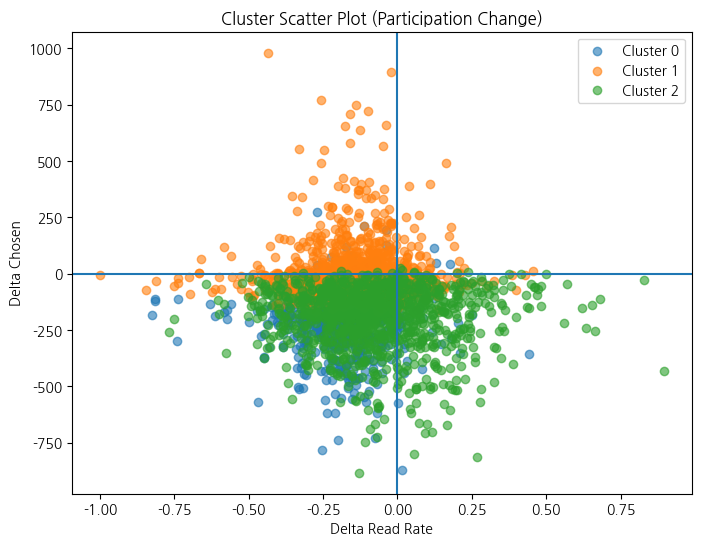

In [57]:
# 2. 참여 구조 변화 기준 산점도
plt.figure(figsize=(8,6))

for cluster in sorted(df['cluster_id'].unique()):
    subset = df[df['cluster_id'] == cluster]
    plt.scatter(
        subset['delta_read_rate'],
        subset['delta_chosen'],
        label=f'Cluster {cluster}',
        alpha=0.6
    )

plt.axhline(0)
plt.axvline(0)

plt.xlabel('Delta Read Rate')
plt.ylabel('Delta Chosen')
plt.title('Cluster Scatter Plot (Participation Change)')
plt.legend()
plt.show()

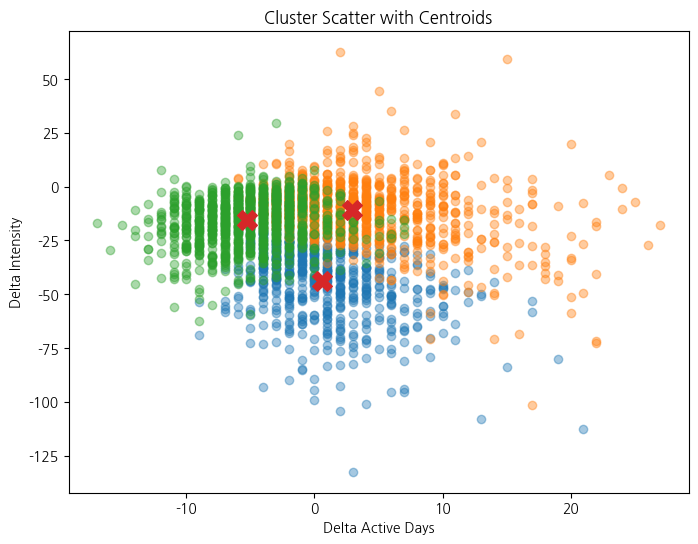

In [58]:
# 3. 클러스터 중심정(centroid) 같이 표시)
plt.figure(figsize=(8,6))

for cluster in sorted(df['cluster_id'].unique()):
    subset = df[df['cluster_id'] == cluster]
    plt.scatter(
        subset['delta_active_days'],
        subset['delta_intensity'],
        alpha=0.4
    )

# 중심점 계산 (원본 스케일 기준)
centers = df.groupby('cluster_id')[['delta_active_days','delta_intensity']].mean()

plt.scatter(
    centers['delta_active_days'],
    centers['delta_intensity'],
    s=200,
    marker='X'
)

plt.xlabel('Delta Active Days')
plt.ylabel('Delta Intensity')
plt.title('Cluster Scatter with Centroids')
plt.show()

# 5. 기능별 문제 정의(클러스터 × 기능 지표 테이블)

## 5.4 네트워크 분석

In [38]:
contacts = accounts_user_contacts_df.copy()

print("📌 연락처 수 기본 통계")
display(contacts['contacts_count'].describe())

📌 연락처 수 기본 통계


count    5063.000000
mean       25.986174
std        13.601434
min         0.000000
25%        16.000000
50%        24.000000
75%        34.000000
max       114.000000
Name: contacts_count, dtype: float64

In [39]:
# 문자열 리스트 → 실제 리스트 변환
contacts['invite_user_id_list'] = contacts['invite_user_id_list'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)


In [40]:
invite_edges = contacts.explode('invite_user_id_list')

invite_edges = invite_edges[
    invite_edges['invite_user_id_list'].notnull()
]

invite_edges = invite_edges.rename(columns={
    'user_id': 'invited_user',
    'invite_user_id_list': 'inviter_user'
})

invite_edges[['inviter_user', 'invited_user']].head()

,inviter_user,invited_user
2,854615,857205
4,849318,855476
5,855829,1482744
6,849318,854615
6,849421,854615


In [41]:
# 초대한 사람 수
inviter_count = (
    invite_edges.groupby('inviter_user')['invited_user']
    .count()
    .sort_values(ascending=False)
)

# 초대받은 사람 수
invited_count = (
    invite_edges.groupby('invited_user')['inviter_user']
    .count()
    .sort_values(ascending=False)
)

G = nx.DiGraph()

# 엣지 추가
for _, row in invite_edges.iterrows():
    G.add_edge(row['inviter_user'], row['invited_user'])

print("노드 수:", G.number_of_nodes())
print("엣지 수:", G.number_of_edges())

노드 수: 2104
엣지 수: 1687


In [42]:
# PageRank 계산
pr = nx.pagerank(G)

# 상위 50명만 추출
top_nodes = sorted(pr, key=pr.get, reverse=True)[:50]

# 서브그래프 생성
H = G.subgraph(top_nodes)

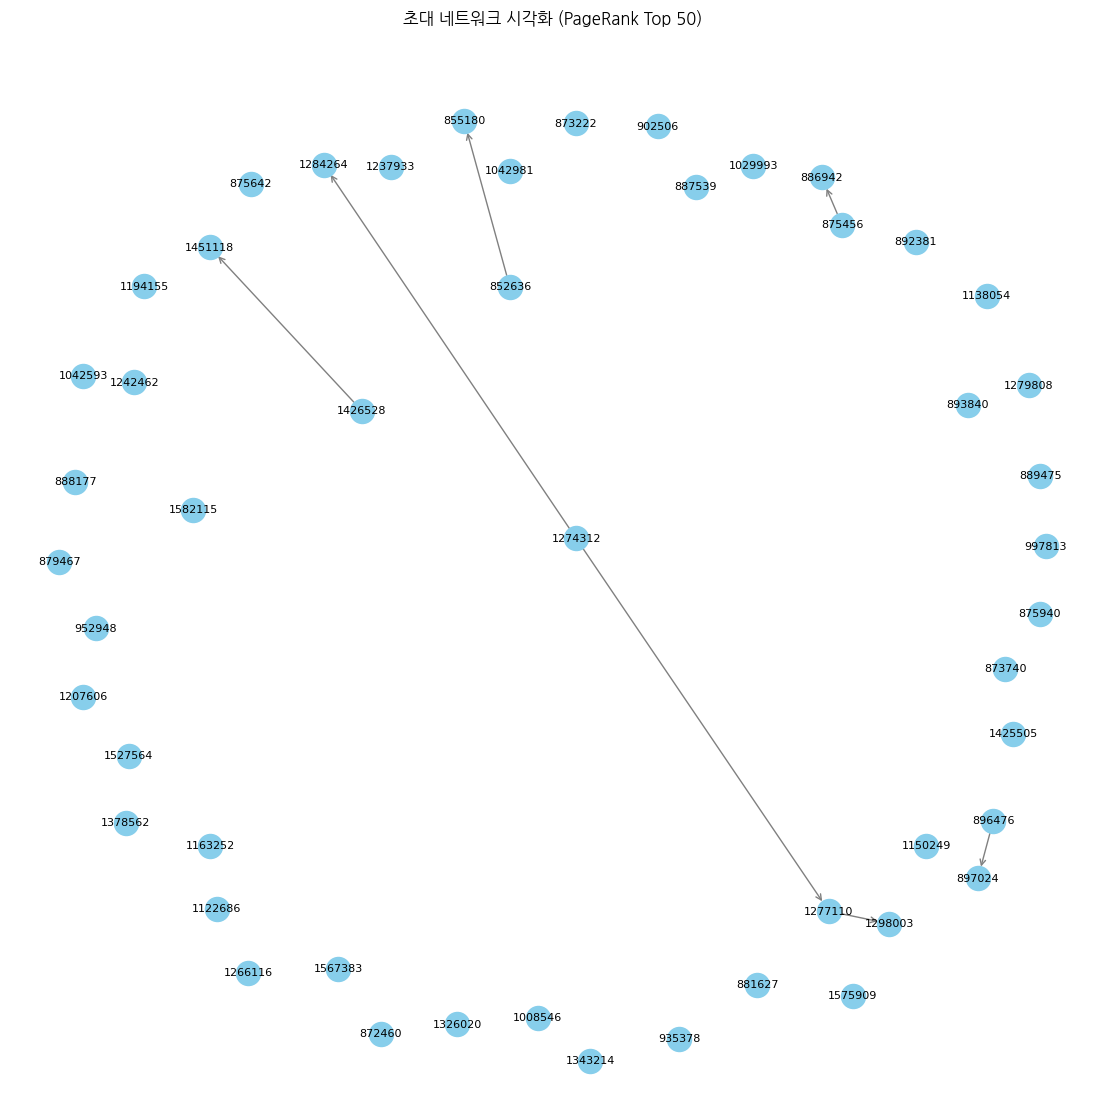

In [43]:
plt.figure(figsize=(14, 14))

pos = nx.spring_layout(H, k=0.3, iterations=50)

nx.draw_networkx_nodes(H, pos, node_size=300, node_color='skyblue')
nx.draw_networkx_edges(H, pos, arrowstyle='->', arrowsize=10, edge_color='gray')
nx.draw_networkx_labels(H, pos, font_size=8)

plt.title("초대 네트워크 시각화 (PageRank Top 50)")
plt.axis('off')
plt.show()